# Customer Satisfaction: PCA, Regularization and Boosting

Built a reproducible customer-satisfaction benchmark on 76,020 records, comparing regularization, PCA and gradient boosting. Used duplicate-aware partitions and training-only preprocessing to prevent leakage. The selected gradient-boosting model achieved held-out ROC-AUC 0.836 versus 0.779 for the same-split logistic baseline, with average precision improving from 0.142 to 0.194. Documented the limits of accuracy on a highly imbalanced target.

This notebook reviews saved results. The experiment script was executed separately. Enable the optional rerun only after configuring your dataset.

## Method

Compared regularized logistic regression, 128-component PCA plus logistic regression, and histogram gradient boosting. Identical predictor rows stay in the same partition, including rows with conflicting labels. Scaling, feature filtering and PCA are fitted on training data. The validation partition selects the model by ROC-AUC; the selected model is refitted on development data and evaluated on the held-out test partition.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image
root = Path.cwd()
metrics = json.loads((root / 'results' / 'metrics.json').read_text(encoding='utf8'))
if 'test_results' in metrics:
    display(pd.DataFrame(metrics['test_results']).T)
else:
    display(pd.DataFrame({'value': {k:v for k,v in metrics.items() if isinstance(v,(str,int,float))}}))

,accuracy,balanced_accuracy,macro_f1,weighted_f1,roc_auc,average_precision
L2 logistic baseline,0.960208,0.503083,0.496373,0.941420,0.779454,0.141673
PCA128 + L2,0.960339,0.503947,0.498037,0.941614,0.781002,0.143644
HistGradientBoosting leaves15,0.960537,0.501661,0.493245,0.941333,0.835737,0.193810


## Recorded environment and data provenance

In [2]:
display(metrics.get('environment', {}))
print('Data fingerprint:', metrics.get('input_sha256', metrics.get('audit',{}).get('input_sha256','see dataset checksums')))

{'python': '3.12.2',
 'numpy': '2.5.3',
 'pandas': '3.0.6',
 'sklearn': '1.9.1',
 'scipy': '1.18.1',
 'seed': 42}

Data fingerprint: 3a3214dbcca233c4f066a2017e33fffc7789cb2c9fc5c09c3a76fe22f9c2954e


## Figures

test_confusion_matrix.png


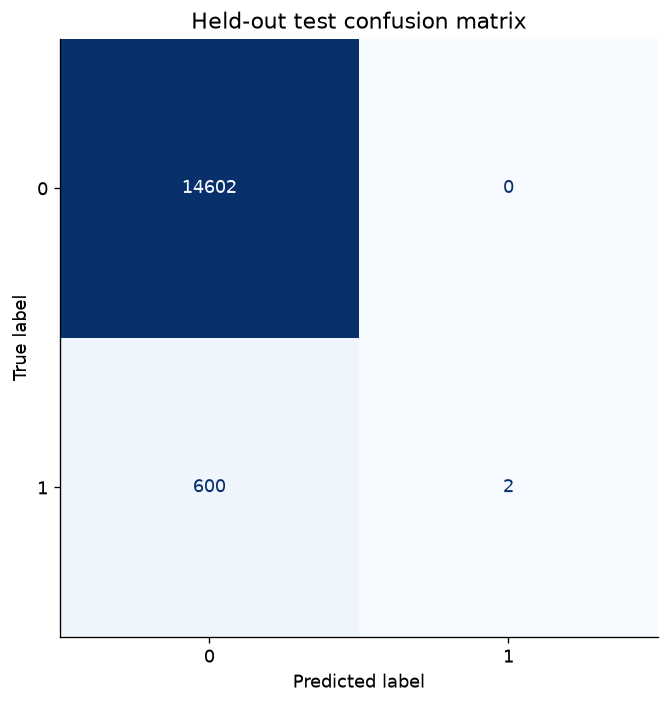

threshold_selection.png


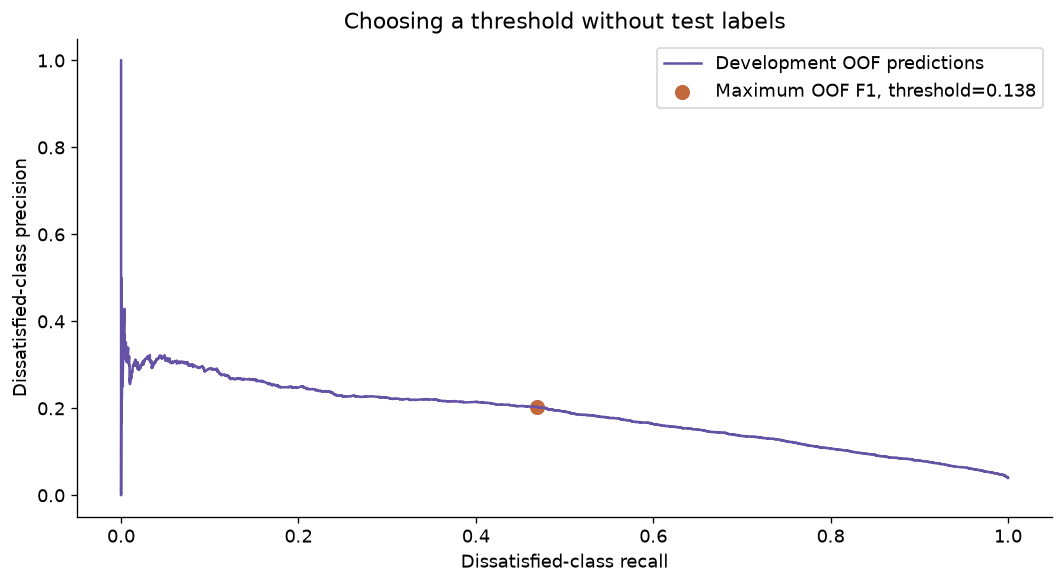

threshold_test_confusion_matrix.png


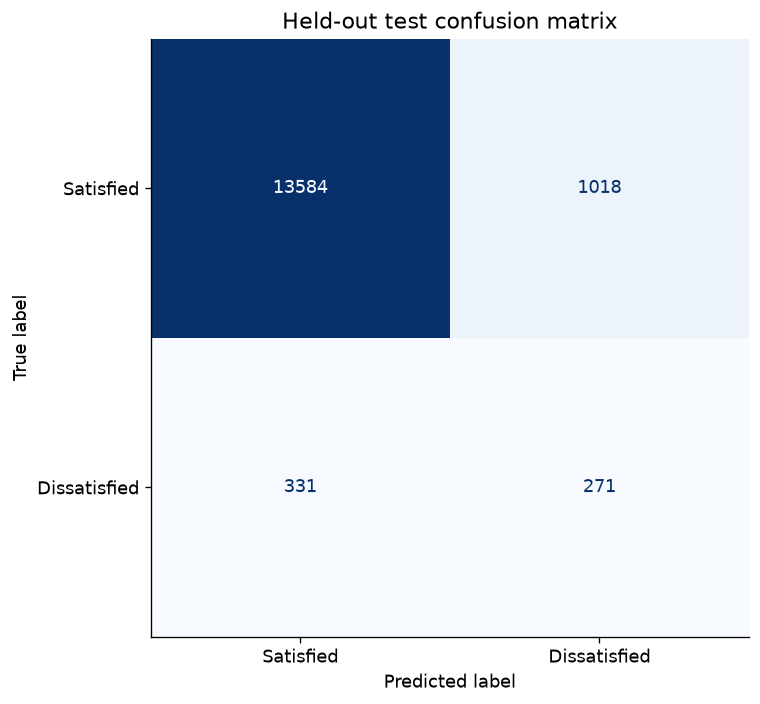

validation_comparison.png


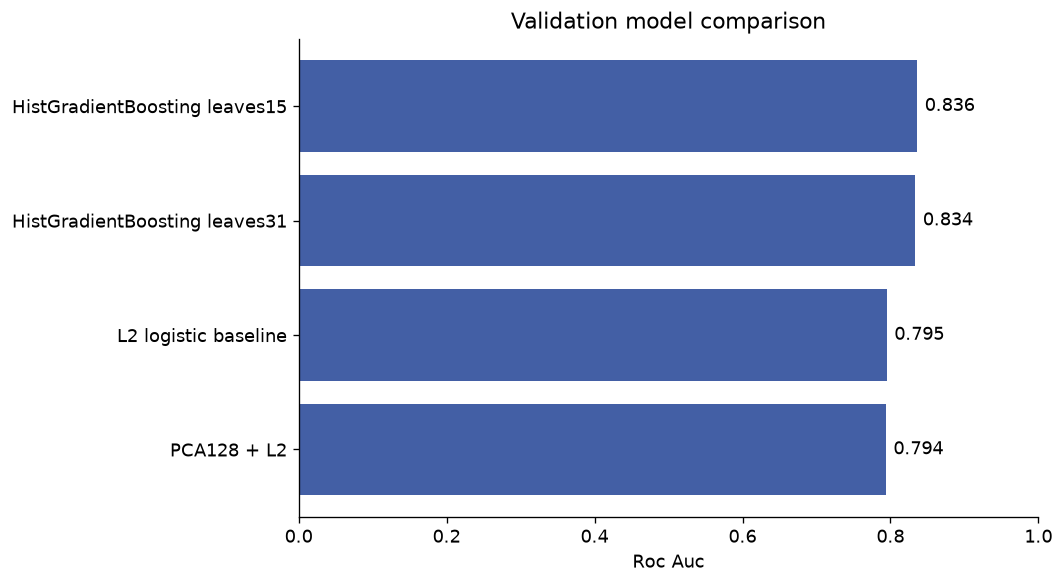

In [3]:
for figure in sorted((root / 'results').glob('*.png')):
    print(figure.name)
    display(Image(filename=str(figure)))

## Interpretation and limitations

The target is rare: a majority-only classifier already achieves about 96% accuracy. Report ROC-AUC and average precision, not accuracy as evidence of strong detection. At the default 0.5 threshold, minority recall remains very low; operational threshold/cost calibration is future work. The historical cross-validation score is not directly comparable to this new test split.

## Optional full rerun

Adjust the dataset path in the command. This may download files or train a model and can take time. Results below are never produced from synthetic placeholder data.

In [4]:
RERUN_EXPERIMENT = False
if RERUN_EXPERIMENT:
    import subprocess, sys, shlex
    command = 'python train.py --data data/train.csv --out results'
    subprocess.run([sys.executable] + shlex.split(command)[1:], cwd=root, check=True)